# Data wrangling and transformation

Let's start by making a new kind of chart.

## ECDF charts

In [ ]:
library('palmerpenguins')
library('ggplot2')

In [ ]:
ggplot(penguins, aes(x = body_mass_g, fill = species)) + 
    geom_histogram(position = 'identity', alpha = 0.65, na.rm = TRUE) +
    scale_fill_brewer(palette = 'Set2')

In [ ]:
ggplot(penguins, aes(x = body_mass_g, color = species)) + 
    stat_ecdf(geom = "step") +
    scale_fill_brewer(palette = 'Set2')

This is great but `ggplot2` does not support every statistic. Let's calulate a variable for the y-encoding explicitly.

$$ \text{ECDF}(x) = \frac{\text{Number of data points } \le x}{\text{Total number of data points}} $$


In [ ]:
library('dplyr')

In [ ]:
penguins |>
    # group_by(species) |>
    mutate(
        cumul_count = rank(body_mass_g, ties.method = 'max'),  # number of data points <= x
        ecdf_value = cumul_count / n()                         # divide by total number of data points
    ) |>
    head() |> display()
# ggplot(aes(x = body_mass_g, y = ecdf_value, group = species)) + geom_step(direction = 'vh')

---

## Examples from *Hello Data Science*

The code below is adapted from Chapter 5, "Dealing with Variables:
Transformation and Aggregation", of:

> Doğucu, M., Medina, C., & Castro, A. *Hello Data Science: A Friendly
> Introduction with Applications.* <https://hellodata.science/chapters/chapter-05>

Licensed CC BY-NC-ND 4.0. Only change: `library(tidyverse)` becomes the
individual packages this browser kernel provides.

### The data

In [ ]:
library('hellodatascience')

In [ ]:
data(penn_world)

glimpse(penn_world)

### The pipe

Three ways to write the same thing.

In [ ]:
round(mean(c(4, 8, 16)))

In [ ]:
numbers <- c(4, 8, 16)
avg_number <- mean(numbers)

round(avg_number)

In [ ]:
c(4, 8, 16) |>
  mean() |>
  round()

### Changing variable names

`clean_names()` lowercases names and turns spaces into underscores.

In [ ]:
janitor::clean_names(penn_world) |>
    names()

In [ ]:
penn_world |>
    janitor::clean_names() |>
    rename(employment = emp) |>
    names()

In [ ]:
penn_world <-
    penn_world |>
    janitor::clean_names() |>
    rename(employment = emp)

penn_world |> head() |> display()

In [ ]:
x <-
  -3.14159 |>
  abs() |>
  round()

x

In [ ]:
c(9, 144, 1, 49) |>
  sort() |>
  sqrt()

### Subsetting columns with `select()`

In [ ]:
penn_world |>
  select(country, pl_consumption)

In [ ]:
penn_world |>
    select(!c(country_code, real_gdp_expenditure)) |>
    glimpse()

In [ ]:
penn_world |>
    select(
        country,
        currency_unit,
        year,
        population,
        starts_with('pl')
    ) |>
    glimpse()

### Subsetting rows with `filter()` and `slice()`

In [ ]:
penn_world |>
    filter(year == 2019) |>
    glimpse()

In [ ]:
penn_world |>
    filter(currency_unit == 'Euro' & year == 2019) |>
    glimpse()

In [ ]:
penn_world |>
    filter(
        country == 'Canada' |
        country == 'United States' |
        country == 'Mexico'
    ) |>
    glimpse()

In [ ]:
penn_world |>
  slice(3:6)

In [ ]:
penn_world <-
    penn_world |>
    select(
        country,
        population,
        year,
        currency_unit,
        pl_exports,
        pl_imports
    )

### Changing variable type

In [ ]:
penn_world |>
    mutate(year = as.integer(year)) |>
    glimpse()

### New variables from operations

In [ ]:
penn_world |>
    mutate(trade_balance = pl_exports - pl_imports) |>
    glimpse()

In [ ]:
penn_world |>
    mutate(population = population * 1000000) |>
    glimpse()

### New variables from conditions

In [ ]:
penn_world |>
    mutate(
    eurozone = if_else(
      currency_unit == 'Euro',
      'In Euro Zone',
      'Not In Euro Zone'
    )) |> 
    glimpse()

In [ ]:
penn_world |>
    mutate(
    eurozone = if_else(
      currency_unit == 'Euro',
      TRUE,
      FALSE
    )) |> 
    select(country, currency_unit, eurozone) |>
    glimpse()

In [ ]:
penn_world <-
    penn_world |>
    mutate(
    eurozone = if_else(
      currency_unit == 'Euro',
      TRUE,
      FALSE
    )) |>
    glimpse()

`case_when()` handles more than two cases.

In [ ]:
penn_world |>
    mutate(
    decade = case_when(
      year >= 1990 & year < 2000 ~ '1990s',
      year >= 2000 & year < 2010 ~ '2000s',
      year >= 2010 & year < 2020 ~ '2010s'
    )) |>
    glimpse()

Rows matching no condition get `NA`.

In [ ]:
data_frame <- data.frame(x = c(0, 2, 4))

data_frame |>
  mutate(
    z = case_when(
      x > 3 ~ 'Greater than 3',
      x > 1 ~ 'Greater than 1'
    )
  ) |> glimpse()

### Aggregating

In [ ]:
penn_world |>
    filter(year == 2019) |>
    group_by(eurozone) |>
    glimpse()

In [ ]:
penn_world |>
    filter(year == 2019) |>
    group_by(eurozone) |>
    summarize(mean_exports = mean(pl_exports)) |>
    glimpse()

## Example from OutlierConf

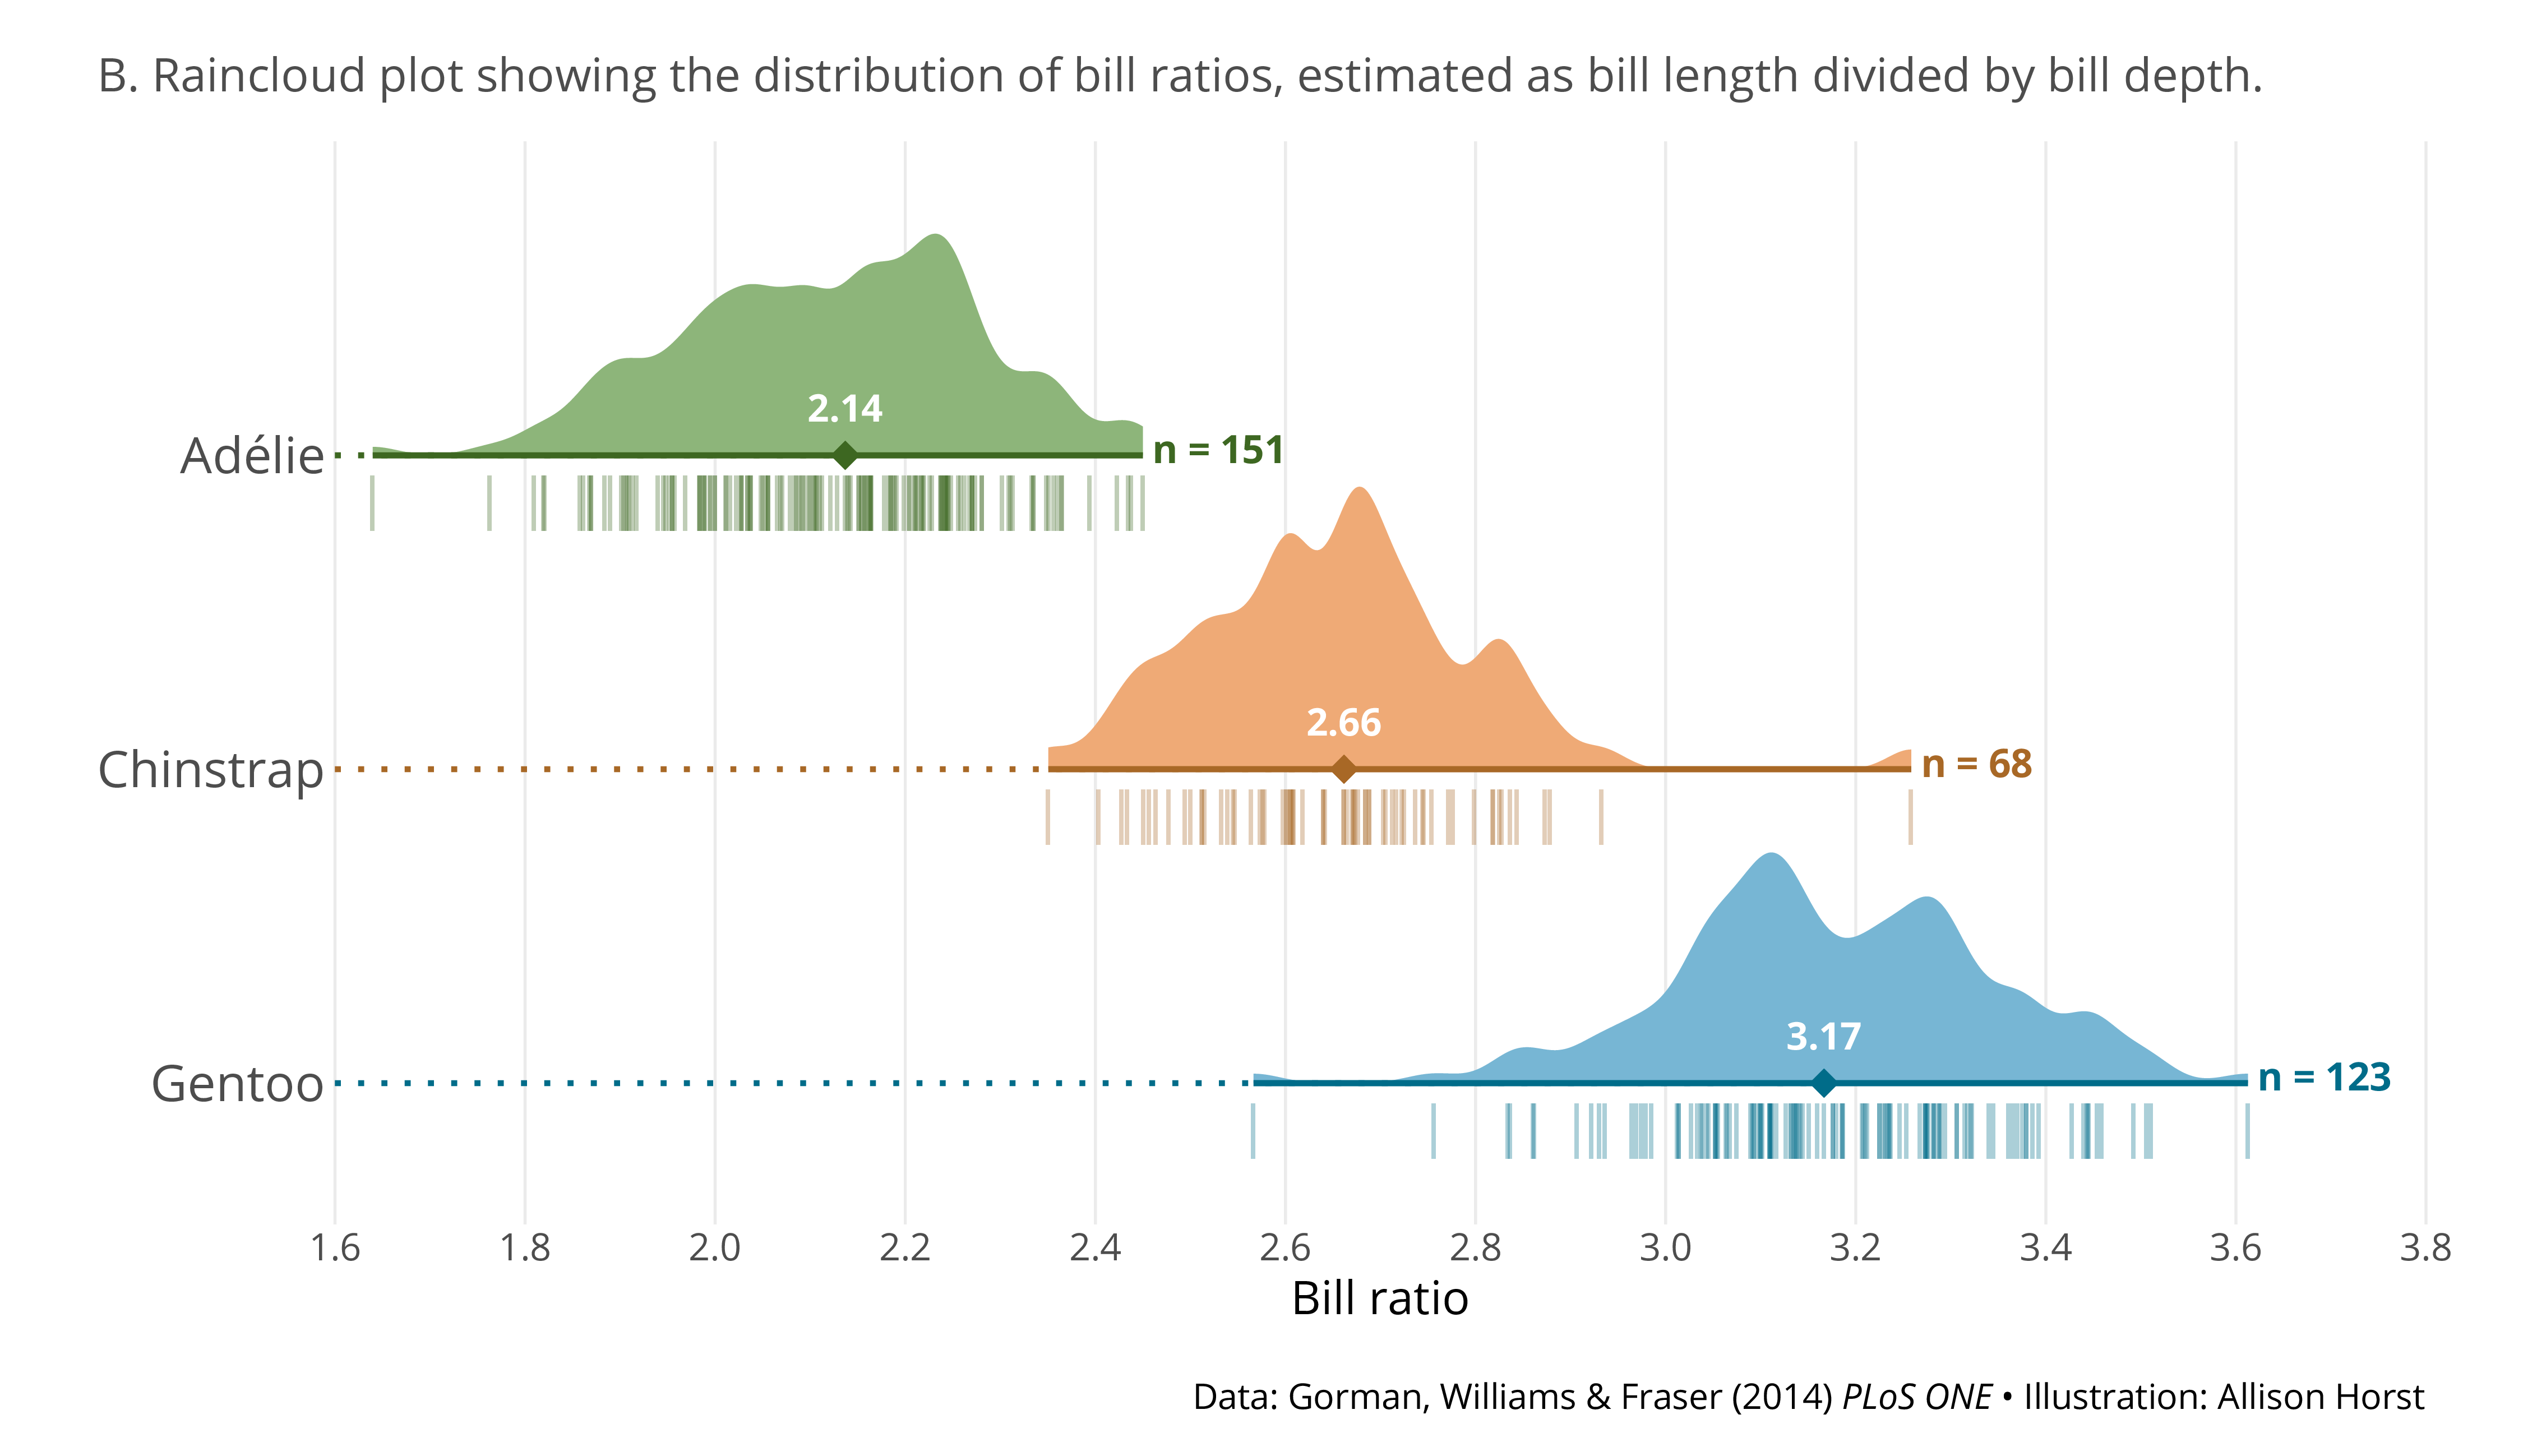

In [ ]:
penguins |>
    mutate(bill_ratio = bill_length_mm / bill_depth_mm) |>
    filter(!is.na(bill_ratio)) |>
    group_by(species) |>
    mutate(
        n = n(),
        median = median(bill_ratio),
        max = max(bill_ratio)
    ) |>
    ungroup() |>
    mutate(species_num = as.numeric(forcats::fct_rev(species))) |>
    glimpse()